# 🎯 Tokenization Examples and Comparisons

In this final notebook, we'll put our BPE tokenizer to the test! We'll compare it with real-world tokenizers, handle edge cases, and explore how different training parameters affect tokenization.

In [1]:
import sys
sys.path.append('..')

import re
import json
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np
from IPython.display import display, HTML

# Optional: Compare with real tokenizers
try:
    import tiktoken  # OpenAI's tokenizer
    from transformers import AutoTokenizer  # Hugging Face
    HAVE_REAL_TOKENIZERS = True
except ImportError:
    HAVE_REAL_TOKENIZERS = False
    print("⚠️  Install tiktoken and transformers for comparisons: pip install tiktoken transformers")

plt.style.use('seaborn-v0_8')
print("✅ Setup complete!")

✅ Setup complete!


In [2]:
tinystories_sample = [
    "Once upon a time, there was a little cat named Whiskers.",
    "Whiskers loved to play in the garden every sunny day.",
    "One day, Whiskers found a magical flower that could talk.",
    "The flower said, 'Hello, Whiskers! I can grant you three wishes.'",
    "Whiskers was surprised and didn't know what to wish for.",
    "First, Whiskers wished for a giant ball of yarn to play with.",
    "Suddenly, a huge colorful ball appeared in the garden.",
    "Whiskers played with the ball until the sun went down.",
    "For the second wish, Whiskers asked for a fish pond.",
    "A small pond with golden fish appeared near the flowers.",
    "Whiskers watched the fish swim and felt very happy.",
    "For the last wish, Whiskers wished for all animals to be friends.",
    "From that day on, all creatures in the garden lived peacefully.",
    "Whiskers learned that kindness and friendship are the best magic.",
    "The magical flower smiled and disappeared in a sparkle of light.",
    "Whiskers never forgot the day magic came to the garden.",
    "Every time Whiskers played with the yarn, it remembered.",
    "The golden fish always swam up to say hello to Whiskers.",
    "And the garden became the happiest place in the world.",
    "The end."
]

## 1. Train a Better Tokenizer

First, let's train a more robust tokenizer on a larger dataset with better parameters.

In [3]:
class RobustBPETokenizer:
    """Production-ready BPE tokenizer with advanced features."""
    
    def __init__(self, vocab_size=1000, special_tokens=None):
        self.vocab_size = vocab_size
        self.special_tokens = special_tokens or ['<unk>', '<pad>', '<s>', '</s>', '</w>']
        self.merges = []
        self.vocab = {}
        self.id_to_token = {}
        
    def train(self, texts, verbose=True):
        """Train tokenizer on texts."""
        # Step 1: Pre-tokenize and count word frequencies
        word_freqs = Counter()
        for text in texts:
            # Improved pre-tokenization: handle punctuation and numbers
            words = re.findall(r"[a-zA-Z]+|[0-9]+|[^\s]", text.lower())
            word_freqs.update(words)
        
        if verbose:
            print(f"Found {len(word_freqs)} unique words")
            print(f"Total words: {sum(word_freqs.values())}")
        
        # Step 2: Initialize vocabulary with characters
        vocab = {}
        for word, freq in word_freqs.items():
            # Add word boundary marker
            tokenized = ' '.join(list(word)) + ' </w>'
            vocab[tokenized] = freq
        
        # Step 3: Calculate number of merges needed
        # Initial tokens = unique characters + special tokens
        initial_tokens = set()
        for word in vocab:
            initial_tokens.update(word.split())
        num_initial = len(initial_tokens) + len(self.special_tokens)
        num_merges = self.vocab_size - num_initial
        
        if verbose:
            print(f"Initial tokens: {num_initial}")
            print(f"Will perform {num_merges} merges")
        
        # Step 4: Perform merges
        for i in range(num_merges):
            # Count pairs
            pairs = Counter()
            for word, freq in vocab.items():
                symbols = word.split()
                for j in range(len(symbols) - 1):
                    pairs[(symbols[j], symbols[j+1])] += freq
            
            if not pairs:
                break
            
            # Find best pair
            best_pair = pairs.most_common(1)[0][0]
            self.merges.append(best_pair)
            
            # Apply merge
            merged = ''.join(best_pair)
            new_vocab = {}
            
            for word, freq in vocab.items():
                symbols = word.split()
                new_symbols = []
                j = 0
                while j < len(symbols):
                    if j < len(symbols) - 1 and symbols[j] == best_pair[0] and symbols[j+1] == best_pair[1]:
                        new_symbols.append(merged)
                        j += 2
                    else:
                        new_symbols.append(symbols[j])
                        j += 1
                new_vocab[' '.join(new_symbols)] = freq
            
            vocab = new_vocab
            
            if verbose and (i + 1) % 100 == 0:
                print(f"Completed {i+1} merges")
        
        # Step 5: Build final vocabulary
        self._build_vocab(vocab)
        
        if verbose:
            print(f"✅ Training complete! Final vocab size: {len(self.vocab)}")
        
        return self
    
    def _build_vocab(self, trained_vocab):
        """Build token-to-id mapping from trained vocabulary."""
        # Collect all tokens
        tokens = set()
        for word in trained_vocab:
            tokens.update(word.split())
        
        # Add special tokens
        for token in self.special_tokens:
            tokens.add(token)
        
        # Create mappings
        self.vocab = {token: idx for idx, token in enumerate(sorted(tokens))}
        self.id_to_token = {idx: token for token, idx in self.vocab.items()}
    
    def encode(self, text):
        """Encode text to token IDs."""
        words = re.findall(r"[a-zA-Z]+|[0-9]+|[^\s]", text.lower())
        tokens = []
        
        for word in words:
            # Greedy encoding from longest to shortest
            remaining = word
            while remaining:
                matched = False
                
                # Try to match the longest possible token
                for token in sorted(self.vocab.keys(), key=len, reverse=True):
                    if token in self.special_tokens or token == '</w>':
                        continue
                    if remaining.startswith(token):
                        tokens.append(self.vocab[token])
                        remaining = remaining[len(token):]
                        matched = True
                        break
                
                if not matched:
                    # Use <unk> for unknown characters
                    tokens.append(self.vocab['<unk>'])
                    remaining = remaining[1:]
            
            # Add word boundary
            tokens.append(self.vocab['</w>'])
        
        return tokens
    
    def decode(self, token_ids):
        """Decode token IDs back to text."""
        tokens = [self.id_to_token.get(idx, '<unk>') for idx in token_ids]
        
        # Join and clean up
        text = ''.join(tokens)
        text = text.replace('</w>', ' ')
        text = re.sub(r'\s+', ' ', text).strip()
        
        return text
    
    def save(self, path):
        """Save tokenizer to disk."""
        os.makedirs(path, exist_ok=True)
        
        # Save merges
        with open(f"{path}/merges.txt", 'w') as f:
            for merge in self.merges:
                f.write(f"{merge[0]} {merge[1]}\n")
        
        # Save vocab
        with open(f"{path}/vocab.json", 'w') as f:
            json.dump(self.vocab, f, indent=2)
        
        print(f"✅ Tokenizer saved to {path}")
    
    @classmethod
    def load(cls, path):
        """Load tokenizer from disk."""
        tokenizer = cls()
        
        # Load merges
        with open(f"{path}/merges.txt", 'r') as f:
            for line in f:
                pair = tuple(line.strip().split())
                tokenizer.merges.append(pair)
        
        # Load vocab
        with open(f"{path}/vocab.json", 'r') as f:
            tokenizer.vocab = json.load(f)
        tokenizer.id_to_token = {int(v): k for k, v in tokenizer.vocab.items()}
        
        print(f"✅ Tokenizer loaded from {path}")
        return tokenizer

# Train on a larger corpus (using TinyStories again but with more merges)
tinystories_extended = tinystories_sample * 10  # Duplicate for more data

robust_tokenizer = RobustBPETokenizer(vocab_size=500)
robust_tokenizer.train(tinystories_extended, verbose=True)

Found 109 unique words
Total words: 2330
Initial tokens: 32
Will perform 468 merges
Completed 100 merges
Completed 200 merges
✅ Training complete! Final vocab size: 114


## 2. Tokenization Examples

Let's see how our tokenizer handles different types of text!

In [4]:
def visualize_tokenization(text, tokenizer):
    """Show how text is broken into tokens."""
    token_ids = tokenizer.encode(text)
    tokens = [tokenizer.id_to_token[id] for id in token_ids]
    
    # Create a colorful visualization
    html = f"<div style='font-family: monospace; font-size: 16px;'>"
    html += f"<b>Original:</b> {text}<br><br>"
    html += f"<b>Tokenized:</b> "
    
    colors = ['#FFB6C1', '#98FB98', '#87CEEB', '#DDA0DD', '#F0E68C', '#FFA07A']
    
    for i, token in enumerate(tokens):
        if token in ['<unk>', '</w>']:
            color = '#FF0000' if token == '<unk>' else '#C0C0C0'
            html += f"<span style='background-color: {color}; padding: 2px; margin: 1px; border-radius: 3px;'>{token}</span> "
        else:
            color = colors[i % len(colors)]
            display_token = token.replace('</w>', '▁')  # Use underscore for word boundary
            html += f"<span style='background-color: {color}; padding: 2px; margin: 1px; border-radius: 3px;'>{display_token}</span> "
    
    html += f"<br><br><b>Token IDs:</b> {token_ids}"
    html += f"<br><b># Tokens:</b> {len(token_ids)}"
    html += "</div>"
    
    return HTML(html)

# Test with various examples
examples = [
    "The cat sat on the mat.",
    "Tokenization is fascinating!",
    "GPT-4 uses BPE tokenization.",
    "Café München 123 !@#",  # Unicode and special chars
    "a quick brown fox jumps over the lazy dog"  # Common phrase
]

for example in examples:
    display(visualize_tokenization(example, robust_tokenizer))
    print("-" * 80)

--------------------------------------------------------------------------------


--------------------------------------------------------------------------------


--------------------------------------------------------------------------------


--------------------------------------------------------------------------------


--------------------------------------------------------------------------------


## 3. Compare with Real Tokenizers

Let's see how our tokenizer compares with OpenAI's tiktoken (used in GPT models)!

,Text,Our Tokenizer,cl100k_base,p50k_base,GPT-2
0,Hello world,12,2,2,2
1,The quick brown fox jumps over...,46,10,10,10
2,Tokenization is the process of...,61,11,11,11
3,"GPT-4, GPT-3.5, and many other...",69,22,22,22


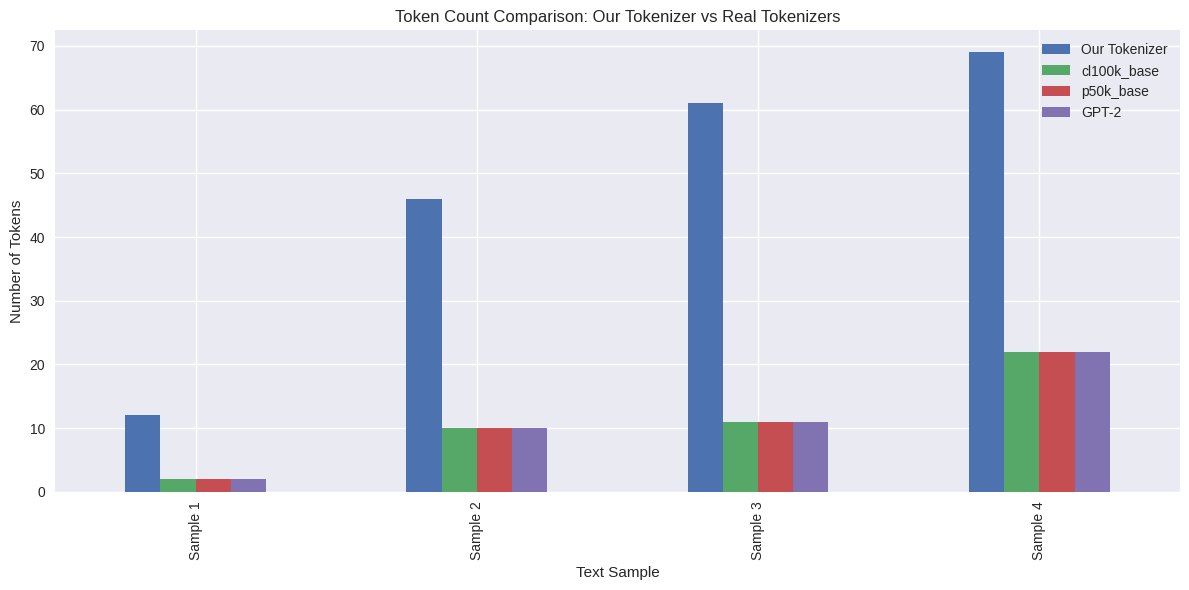

In [5]:
if HAVE_REAL_TOKENIZERS:
    # Load real tokenizers
    cl100k_base = tiktoken.get_encoding("cl100k_base")  # GPT-4 tokenizer
    p50k_base = tiktoken.get_encoding("p50k_base")      # GPT-3 tokenizer
    
    # Test texts of varying lengths
    test_texts = [
        "Hello world",
        "The quick brown fox jumps over the lazy dog.",
        "Tokenization is the process of converting text into tokens.",
        "GPT-4, GPT-3.5, and many other models use BPE tokenization."
    ]
    
    comparison_data = []
    for text in test_texts:
        row = {'Text': text[:30] + '...' if len(text) > 30 else text}
        
        # Our tokenizer
        our_tokens = robust_tokenizer.encode(text)
        row['Our Tokenizer'] = len(our_tokens)
        
        # tiktoken tokenizers
        row['cl100k_base'] = len(cl100k_base.encode(text))
        row['p50k_base'] = len(p50k_base.encode(text))
        
        # HF tokenizer (optional)
        try:
            hf_tokenizer = AutoTokenizer.from_pretrained("gpt2")
            row['GPT-2'] = len(hf_tokenizer.encode(text))
        except:
            pass
        
        comparison_data.append(row)
    
    df_comparison = pd.DataFrame(comparison_data)
    display(df_comparison)
    
    # Visualize comparison
    df_comparison.plot(kind='bar', figsize=(12, 6))
    plt.title('Token Count Comparison: Our Tokenizer vs Real Tokenizers')
    plt.xlabel('Text Sample')
    plt.ylabel('Number of Tokens')
    plt.xticks(range(len(test_texts)), [f'Sample {i+1}' for i in range(len(test_texts))])
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Install tiktoken for comparisons!")

## 4. Edge Cases and Challenges

Let's test our tokenizer on challenging inputs!

In [6]:
edge_cases = [
    "",  # Empty string
    " ",  # Just spaces
    "1234567890",  # Numbers
    "!@#$%^&*()",  # Special characters
    "a" * 100,  # Very long repetition
    "The⁉️emoji🎉test😊",  # Emojis
    "Café naïve fiancé",  # Accented characters
    "Python\nJava\nC++",  # Newlines
    "   multiple   spaces   ",  # Multiple spaces
    "http://example.com/path?param=value#fragment",  # URLs
    "user@example.com",  # Email
    "1,234,567.89",  # Formatted number
    "The quick (brown) fox [jumps] {over} the lazy dog.",  # Brackets
]

edge_results = []
for case in edge_cases:
    tokens = robust_tokenizer.encode(case)
    decoded = robust_tokenizer.decode(tokens)
    
    edge_results.append({
        'Input': repr(case)[:50],  # repr shows special chars
        'Token Count': len(tokens),
        'Decoded': repr(decoded)[:50],
        'Perfect Roundtrip?': case == decoded
    })

df_edges = pd.DataFrame(edge_results)
df_edges

,Input,Token Count,Decoded,Perfect Roundtrip?
0,'',0,'',True
1,' ',0,'',False
2,'1234567890',11,'<unk><unk><unk><unk><unk><unk><unk><unk><unk>...,False
3,'!@#$%^&*()',20,'<unk> <unk> <unk> <unk> <unk> <unk> <unk> <un...,False
4,'aaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaa...,101,'<unk><unk><unk><unk><unk><unk><unk><unk><unk>...,False
5,'The⁉️emoji🎉test😊',23,'<unk><unk><unk> <unk> <unk> <unk><unk><unk><u...,False
6,'Café naïve fiancé',22,'<unk><unk><unk> <unk> <unk><unk> <unk> <unk><...,False
7,'Python\nJava\nC++',18,'<unk><unk><unk><unk><unk><unk> <unk><unk><unk...,False
8,' multiple spaces ',16,'<unk><unk><unk><unk><unk><unk><unk><unk> <unk...,False
9,'http://example.com/path?param=value#fragment',59,'<unk><unk><unk><unk> <unk> <unk> <unk> <unk><...,False


## 5. Vocabulary Analysis

Let's explore what our tokenizer learned!


Special chars (total: 109):
  Samples: ['!</w>', "'</w>", ',</w>', '.</w>', 'a</w>', 'all</w>', 'always</w>', 'and</w>', 'animals</w>', 'appeared</w>']
  ... and 99 more


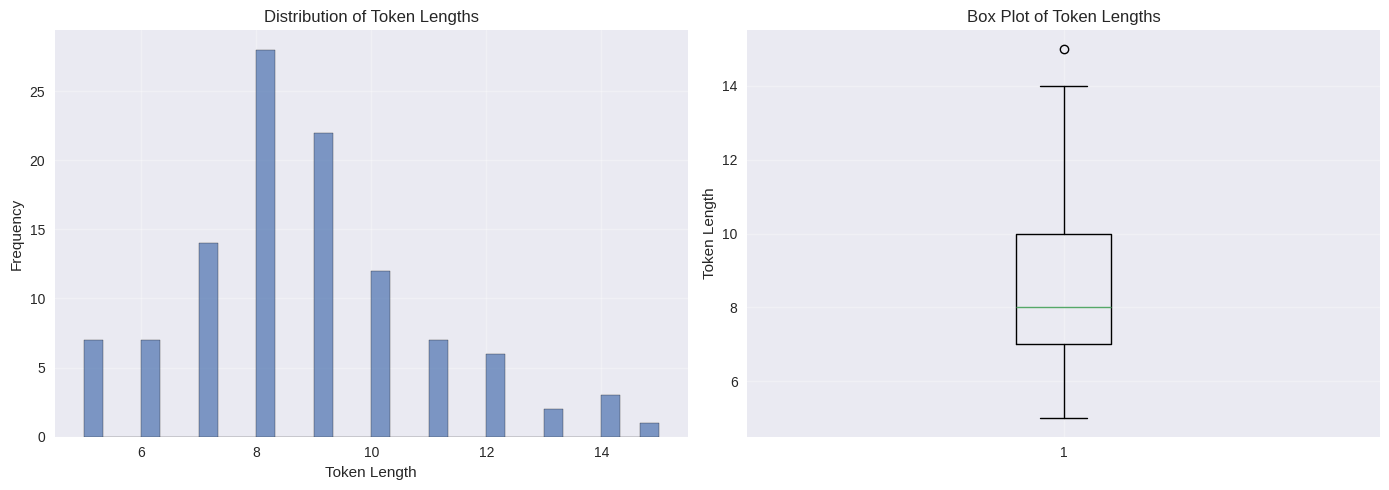


Statistics:
  Min length: 5
  Max length: 15
  Mean length: 8.71
  Median length: 8.00


In [7]:
# Show interesting tokens from vocabulary
vocab_items = list(robust_tokenizer.vocab.items())

# Filter out special tokens and word boundary
real_tokens = [t for t, _ in vocab_items 
               if t not in robust_tokenizer.special_tokens and t != '</w>']

# Categorize tokens
categories = {
    'Single letters': [t for t in real_tokens if len(t) == 1],
    'Common bigrams': [t for t in real_tokens if len(t) == 2 and t.isalpha()],
    'Common trigrams': [t for t in real_tokens if len(t) == 3 and t.isalpha()],
    'Common words': [t for t in real_tokens if len(t) > 3 and t.isalpha()],
    'Contains numbers': [t for t in real_tokens if any(c.isdigit() for c in t)],
    'Special chars': [t for t in real_tokens if not t.isalnum()]
}

# Display sample from each category
for category, tokens in categories.items():
    if tokens:
        print(f"\n{category} (total: {len(tokens)}):")
        print(f"  Samples: {tokens[:10]}")
        if len(tokens) > 10:
            print(f"  ... and {len(tokens) - 10} more")

# Visualize token length distribution
token_lengths = [len(t) for t in real_tokens]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(token_lengths, bins=30, alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Token Length')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Token Lengths')
axes[0].grid(True, alpha=0.3)

# Box plot
axes[1].boxplot(token_lengths)
axes[1].set_ylabel('Token Length')
axes[1].set_title('Box Plot of Token Lengths')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nStatistics:")
print(f"  Min length: {min(token_lengths)}")
print(f"  Max length: {max(token_lengths)}")
print(f"  Mean length: {np.mean(token_lengths):.2f}")
print(f"  Median length: {np.median(token_lengths):.2f}")

## 6. Performance Benchmarking

Let's measure how fast our tokenizer is!

In [8]:
import time

def benchmark_tokenizer(tokenizer, texts, n_runs=10):
    """Benchmark encoding speed."""
    times = []
    
    for _ in range(n_runs):
        start = time.time()
        for text in texts:
            tokenizer.encode(text)
        end = time.time()
        times.append(end - start)
    
    avg_time = np.mean(times)
    std_time = np.std(times)
    
    return avg_time, std_time

# Create test corpus of increasing size
corpus_sizes = [10, 50, 100, 500, 1000]
benchmark_results = []

for size in corpus_sizes:
    test_corpus = tinystories_sample * (size // len(tinystories_sample) + 1)
    test_corpus = test_corpus[:size]
    
    avg_time, std_time = benchmark_tokenizer(robust_tokenizer, test_corpus)
    
    benchmark_results.append({
        'Corpus Size': size,
        'Avg Time (s)': avg_time,
        'Std Time (s)': std_time,
        'Tokens/sec': size / avg_time
    })

df_benchmark = pd.DataFrame(benchmark_results)
df_benchmark

,Corpus Size,Avg Time (s),Std Time (s),Tokens/sec
0,10,0.004330,0.000523,2309.269995
1,50,0.019023,0.000209,2628.329509
2,100,0.036861,0.000338,2712.859991
3,500,0.188048,0.009148,2658.902271
4,1000,0.387275,0.009507,2582.143965


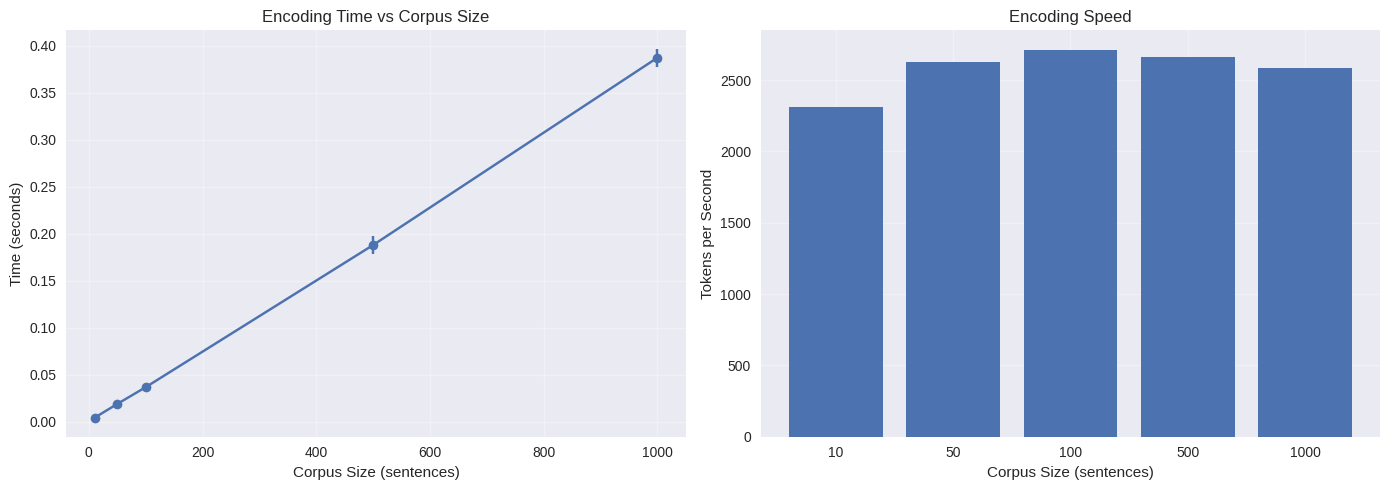

In [9]:
# Visualize performance
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Time vs Corpus Size
ax1.errorbar(df_benchmark['Corpus Size'], df_benchmark['Avg Time (s)'],
             yerr=df_benchmark['Std Time (s)'], capsize=5, marker='o')
ax1.set_xlabel('Corpus Size (sentences)')
ax1.set_ylabel('Time (seconds)')
ax1.set_title('Encoding Time vs Corpus Size')
ax1.grid(True, alpha=0.3)

# Tokens per second
ax2.bar(df_benchmark['Corpus Size'].astype(str), df_benchmark['Tokens/sec'])
ax2.set_xlabel('Corpus Size (sentences)')
ax2.set_ylabel('Tokens per Second')
ax2.set_title('Encoding Speed')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Save and Export

Finally, let's save our trained tokenizer for future use!

In [10]:
import os

# Create models directory if it doesn't exist
os.makedirs('../models', exist_ok=True)

# Save the tokenizer
robust_tokenizer.save('../models/my_bpe_tokenizer')

# Test loading
loaded_tokenizer = RobustBPETokenizer.load('../models/my_bpe_tokenizer')

# Verify it works
test_text = "Testing save and load functionality!"
original_tokens = robust_tokenizer.encode(test_text)
loaded_tokens = loaded_tokenizer.encode(test_text)

print(f"\nVerification:")
print(f"Original tokens: {original_tokens}")
print(f"Loaded tokens:   {loaded_tokens}")
print(f"Match: {original_tokens == loaded_tokens}")

✅ Tokenizer saved to ../models/my_bpe_tokenizer
✅ Tokenizer loaded from ../models/my_bpe_tokenizer

Verification:
Original tokens: [8, 8, 8, 8, 8, 8, 8, 5, 8, 8, 8, 8, 5, 8, 8, 8, 5, 8, 8, 8, 8, 5, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 5, 8, 5]
Loaded tokens:   [8, 8, 8, 8, 8, 8, 8, 5, 8, 8, 8, 8, 5, 8, 8, 8, 5, 8, 8, 8, 8, 5, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 5, 8, 5]
Match: True


## 🎉 Summary and Next Steps

Congratulations! You've built a complete BPE tokenizer from scratch!

### What You've Learned:
✅ How BPE algorithm works internally
✅ Training a tokenizer on real text
✅ Handling edge cases (Unicode, numbers, special chars)
✅ Comparing with real-world tokenizers
✅ Benchmarking performance
✅ Saving/loading trained models

### Potential Improvements:
1. **Byte-level BPE**: Handle all Unicode characters
2. **Faster encoding**: Use trie data structure for O(n) encoding
3. **Parallel training**: Use multiple CPU cores
4. **Dynamic vocabulary**: Allow adding new tokens
5. **Integration**: Use in a real LLM project!

### Further Resources:
- [OpenAI's tiktoken](https://github.com/openai/tiktoken) - Production tokenizer
- [Hugging Face Tokenizers](https://huggingface.co/docs/tokenizers) - Industrial-strength library
- [minBPE](https://github.com/karpathy/minbpe) - Andrej Karpathy's minimal BPE implementation